In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
sns.set_theme(style="whitegrid")

plt.rcParams["figure.figsize"] = (10,6)
plt.rcParams["font.size"] = 12

In [3]:
file_path = "../data/raw/Dados climáticos de 1984 a 2014 - Formatado.xlsx"

In [4]:
dados = pd.read_excel(file_path, sheet_name="dados")

In [5]:
dados.columns = dados.columns.str.strip()

In [6]:
dados.columns.tolist()

['Data',
 'mm/dia - Precipitação',
 'mm/dia - Evapotranspiração',
 'C° - Temperatura Média',
 'W/m² - Radiação']

In [7]:
df_indices = dados[[
"W/m² - Radiação",
"C° - Temperatura Média",
"mm/dia - Precipitação"
]].copy()

In [8]:
df_indices.head()

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação
0,211.801254,25.419519,0.989776
1,204.752853,26.399133,0.166336
2,217.430527,26.202539,0.256648
3,222.075912,26.720331,0.000000
4,220.100525,27.286249,0.000000


In [9]:
df_norm = (df_indices - df_indices.min()) / (df_indices.max() - df_indices.min())

In [10]:
df_norm.head()

,W/m² - Radiação,C° - Temperatura Média,mm/dia - Precipitação
0,0.701174,0.538083,0.018626
1,0.655148,0.676959,0.003130
2,0.737933,0.649089,0.004830
3,0.768267,0.722494,0.000000
4,0.755368,0.802722,0.000000


In [11]:
df_indices["IPS"] = df_norm["W/m² - Radiação"]

In [12]:
df_indices["IECS"] = (
    df_norm["W/m² - Radiação"] +
    df_norm["C° - Temperatura Média"] -
    df_norm["mm/dia - Precipitação"]
)

In [13]:
df_indices[["IPS", "IECS"]].head()

,IPS,IECS
0,0.701174,1.220631
1,0.655148,1.328977
2,0.737933,1.382192
3,0.768267,1.490761
4,0.755368,1.558090


In [14]:
df_indices[["IPS", "IECS"]].describe()

,IPS,IECS
count,11322.000000,11322.000000
mean,0.529163,0.979109
std,0.173776,0.364740
min,0.000000,-0.539176
25%,0.397430,0.701562
50%,0.538515,1.015948
75%,0.663119,1.272415
max,1.000000,1.966594


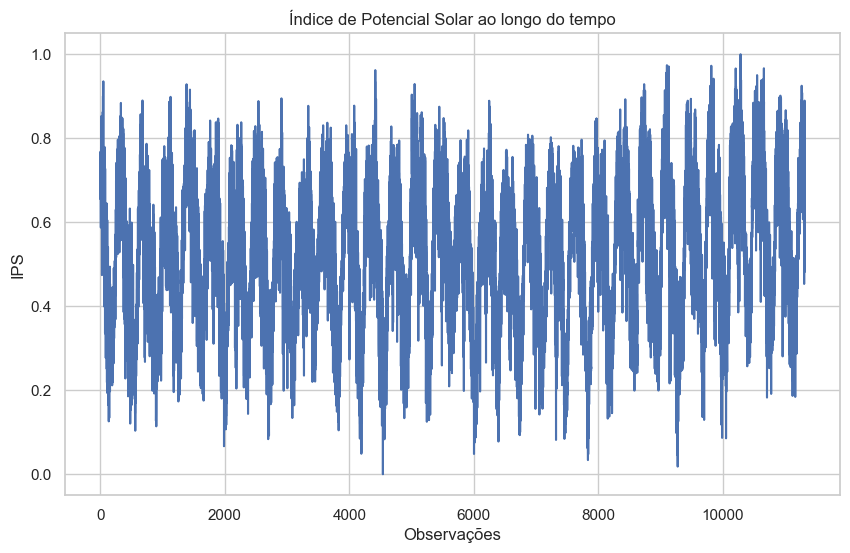

In [15]:
plt.plot(df_indices["IPS"])

plt.title("Índice de Potencial Solar ao longo do tempo")
plt.xlabel("Observações")
plt.ylabel("IPS")

plt.show()

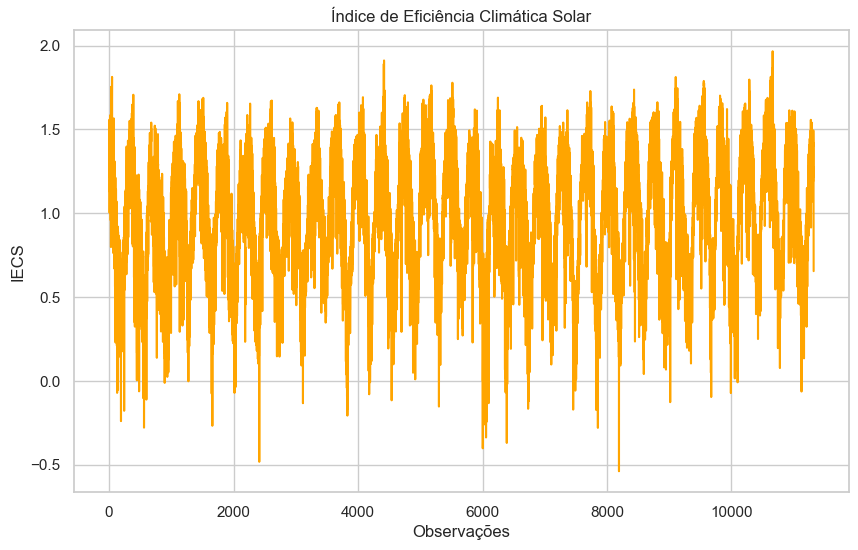

In [16]:
plt.plot(df_indices["IECS"], color="orange")

plt.title("Índice de Eficiência Climática Solar")
plt.xlabel("Observações")
plt.ylabel("IECS")

plt.show()

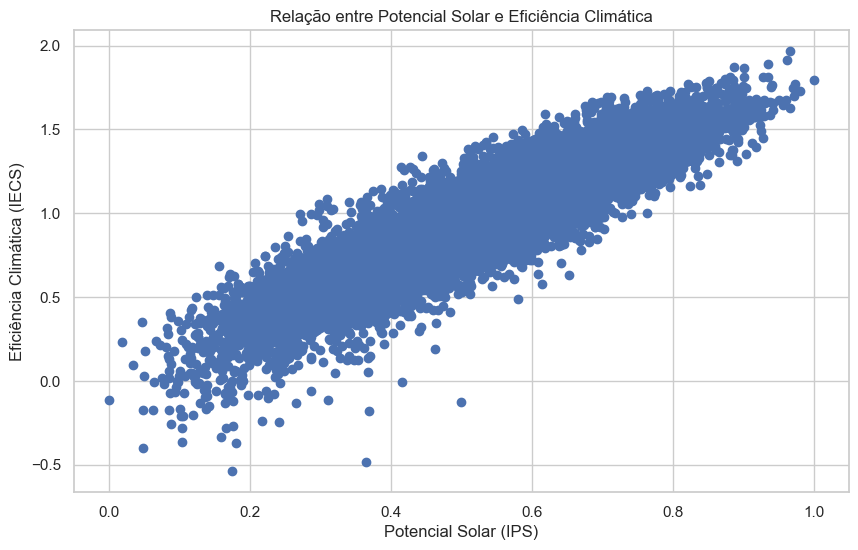

In [17]:
plt.scatter(df_indices["IPS"], df_indices["IECS"])

plt.xlabel("Potencial Solar (IPS)")
plt.ylabel("Eficiência Climática (IECS)")

plt.title("Relação entre Potencial Solar e Eficiência Climática")

plt.show()

## 6. Índices Climáticos para Energia Solar

Nesta etapa, foram construídos dois índices climáticos com o objetivo de sintetizar, de forma simples, o comportamento das variáveis mais importantes para o aproveitamento da energia solar: a **radiação**, a **temperatura média** e a **precipitação**.

A ideia dessa etapa é transformar variáveis climáticas em medidas resumidas que ajudem a interpretar, ao longo do tempo, quando as condições estão mais ou menos favoráveis ao uso da energia solar.

---

## 6.1 Preparação dos dados

Inicialmente, foram selecionadas três variáveis do banco de dados:

- **W/m² - Radiação**
- **C° - Temperatura Média**
- **mm/dia - Precipitação**

Em seguida, os dados foram normalizados pela fórmula min-max:

**X_normalizado = (X - Xmín) / (Xmáx - Xmín)**

Esse procedimento foi necessário para colocar todas as variáveis na mesma escala, variando entre **0 e 1**, evitando que uma variável com valores maiores dominasse o cálculo dos índices.

---

## 6.2 Índice de Potencial Solar (IPS)

O **Índice de Potencial Solar (IPS)** foi definido diretamente a partir da variável de radiação normalizada:

**IPS = Radiação normalizada**

Esse índice representa, de forma simples, o potencial solar disponível em cada observação. Quanto maior o valor do IPS, maior a disponibilidade de radiação solar e, portanto, maior o potencial para aproveitamento fotovoltaico.

### Estatísticas descritivas do IPS

- **Média:** 0,529
- **Desvio padrão:** 0,174
- **Mínimo:** 0,000
- **1º quartil:** 0,397
- **Mediana:** 0,539
- **3º quartil:** 0,663
- **Máximo:** 1,000

### Interpretação do IPS

Os resultados mostram que o IPS variou bastante ao longo da série histórica, refletindo a alternância entre períodos de maior e menor disponibilidade de radiação. Como esse índice depende apenas da radiação, ele funciona como uma medida direta do potencial solar climático.

---

## 6.3 Índice de Eficiência Climática Solar (IECS)

O **Índice de Eficiência Climática Solar (IECS)** foi construído combinando três componentes climáticos:

**IECS = Radiação normalizada + Temperatura normalizada - Precipitação normalizada**

A lógica desse índice é a seguinte:

- **radiação elevada** contribui positivamente;
- **temperatura mais alta** tende a indicar condições atmosféricas mais secas e favoráveis;
- **precipitação elevada** contribui negativamente, pois geralmente está associada à nebulosidade e à redução da radiação disponível.

### Estatísticas descritivas do IECS

- **Média:** 0,979
- **Desvio padrão:** 0,365
- **Mínimo:** -0,539
- **1º quartil:** 0,702
- **Mediana:** 1,016
- **3º quartil:** 1,272
- **Máximo:** 1,967

### Interpretação do IECS

O IECS apresentou maior amplitude que o IPS, pois considera simultaneamente fatores favoráveis e desfavoráveis. Valores mais altos indicam condições climáticas mais adequadas à eficiência solar, enquanto valores baixos ou negativos representam situações menos favoráveis, geralmente associadas a maior precipitação e menor contribuição relativa da radiação.

---

## 6.4 Análise gráfica dos índices

### Comportamento temporal do IPS

O gráfico do IPS ao longo das observações mostrou oscilações frequentes, indicando que o potencial solar varia de forma contínua na série temporal. Mesmo sem usar ainda uma decomposição formal de sazonalidade, já é possível notar a presença de ciclos e flutuações recorrentes.

### Comportamento temporal do IECS

O gráfico do IECS também apresentou variação cíclica ao longo do tempo, mas com amplitude maior do que o IPS, justamente porque incorpora mais de uma variável climática. Isso mostra que a eficiência climática solar depende não apenas da radiação isolada, mas também da combinação entre temperatura e precipitação.

### Relação entre IPS e IECS

No gráfico de dispersão entre IPS e IECS, observou-se uma **relação positiva clara**. Isso indica que, em geral, valores mais altos de potencial solar também estão associados a melhores condições climáticas de eficiência solar.

Em termos práticos, isso significa que quando a radiação aumenta, tende também a haver um cenário climático mais favorável ao aproveitamento solar, principalmente quando a precipitação permanece baixa.

---

## 6.5 Interpretação prática da etapa

Essa etapa foi importante porque transformou variáveis climáticas isoladas em **indicadores sintéticos**, mais fáceis de interpretar. Em vez de analisar apenas colunas separadas de radiação, temperatura e precipitação, os índices permitem resumir a condição climática para energia solar de forma mais objetiva.

De maneira prática:

- o **IPS** mostra o quanto existe de potencial solar disponível;
- o **IECS** mostra o quanto o clima, como um todo, está favorecendo esse aproveitamento.

---

## 6.6 Conclusão da etapa

A construção dos índices climáticos para energia solar foi adequada para complementar a análise exploratória e a modelagem estatística anteriores. O **IPS** permitiu representar diretamente o potencial solar com base na radiação, enquanto o **IECS** incorporou o efeito conjunto de variáveis climáticas favoráveis e desfavoráveis.

Os resultados mostram que os dois índices conseguem representar bem a variabilidade climática da série e ajudam a interpretar, de forma mais resumida, as condições de aproveitamento da energia solar na região estudada.